In [1]:
print("Hello, everything works!")

Hello, everything works!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('KaggleV2-May-2016.csv')

# Basic overview
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
df.head()

Shape: (110527, 14)

Column names: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [3]:
# Check data types and missing values
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nNo-show column values:")
print(df['No-show'].value_counts())

Data types:
PatientId         float64
AppointmentID       int64
Gender             object
ScheduledDay       object
AppointmentDay     object
Age                 int64
Neighbourhood      object
Scholarship         int64
Hipertension        int64
Diabetes            int64
Alcoholism          int64
Handcap             int64
SMS_received        int64
No-show            object
dtype: object

Missing values:
PatientId         0
AppointmentID     0
Gender            0
ScheduledDay      0
AppointmentDay    0
Age               0
Neighbourhood     0
Scholarship       0
Hipertension      0
Diabetes          0
Alcoholism        0
Handcap           0
SMS_received      0
No-show           0
dtype: int64

No-show column values:
No-show
No     88208
Yes    22319
Name: count, dtype: int64


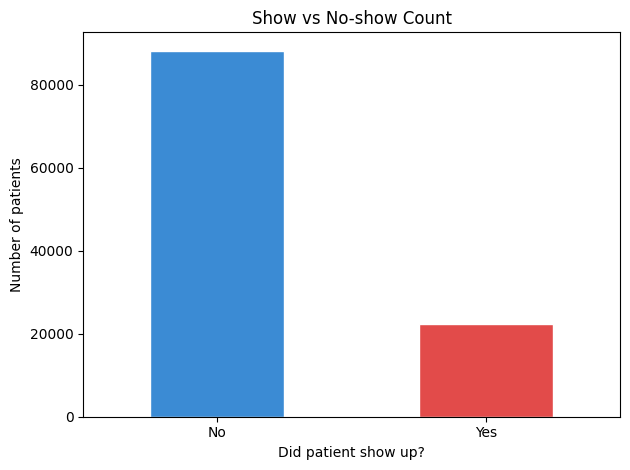

No-show rate: 20.2%


In [4]:
# Visualize no-show distribution
df['No-show'].value_counts().plot(
    kind='bar', 
    color=['#3B8BD4', '#E24B4A'],
    edgecolor='white'
)
plt.title('Show vs No-show Count')
plt.xlabel('Did patient show up?')
plt.ylabel('Number of patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Print the percentage
total = len(df)
noshows = df['No-show'].value_counts()['Yes']
print(f"No-show rate: {noshows/total*100:.1f}%")

No-show rate by SMS:
SMS_received  No-show
0             No         83.3
              Yes        16.7
1             No         72.4
              Yes        27.6
Name: proportion, dtype: float64

No-show rate by Gender:
Gender  No-show
F       No         79.7
        Yes        20.3
M       No         80.0
        Yes        20.0
Name: proportion, dtype: float64


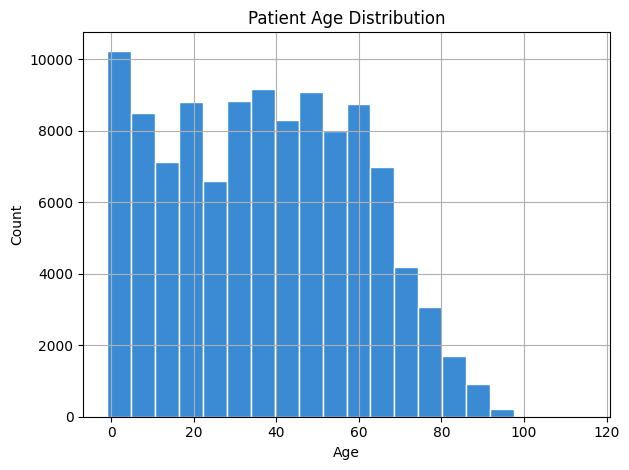

In [ ]:
# No-show rate by SMS received
print("No-show rate by SMS:")
print(df.groupby('SMS_received')['No-show'].value_counts(normalize=True).round(3) * 100)

# No-show rate by Gender
print("\nNo-show rate by Gender:")
print(df.groupby('Gender')['No-show'].value_counts(normalize=True).round(3) * 100)

# Age distribution
df['Age'].hist(bins=20, color='#3B8BD4', edgecolor='white')
plt.title('Patient Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [6]:
# Convert date columns from text to actual dates
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# Create waiting_days — gap between booking and appointment
df['waiting_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# Remove negative waiting days (data errors in the dataset)
df = df[df['waiting_days'] >= 0]

# Check it worked
print("New column created:")
print(df['waiting_days'].describe())
print(f"\nRows remaining: {len(df)}")

New column created:
count    71959.000000
mean        14.642018
std         16.494334
min          0.000000
25%          3.000000
50%          8.000000
75%         21.000000
max        178.000000
Name: waiting_days, dtype: float64

Rows remaining: 71959


In [7]:
# Encode target: Yes=1 (no-show), No=0 (showed up)
df['no_show'] = df['No-show'].map({'Yes': 1, 'No': 0})

# Encode gender: F=0, M=1
df['gender_encoded'] = df['Gender'].map({'F': 0, 'M': 1})

# Extract day of week from appointment (0=Monday, 6=Sunday)
df['appt_dayofweek'] = df['AppointmentDay'].dt.dayofweek

# Drop columns we don't need for ML
drop_cols = [
    'PatientId', 'AppointmentID',
    'ScheduledDay', 'AppointmentDay',
    'Gender', 'No-show', 'Neighbourhood'
]
df_clean = df.drop(columns=drop_cols)

# Rename for clarity
df_clean = df_clean.rename(columns={
    'Hipertension': 'hypertension',
    'Handcap': 'handicap',
    'SMS_received': 'sms_received'
})

print("Final features:", df_clean.columns.tolist())
print("Shape:", df_clean.shape)
df_clean.head()

Final features: ['Age', 'Scholarship', 'hypertension', 'Diabetes', 'Alcoholism', 'handicap', 'sms_received', 'waiting_days', 'no_show', 'gender_encoded', 'appt_dayofweek']
Shape: (71959, 11)


,Age,Scholarship,hypertension,Diabetes,Alcoholism,handicap,sms_received,waiting_days,no_show,gender_encoded,appt_dayofweek
5,76,0,1,0,0,0,0,1,0,0,4
6,23,0,0,0,0,0,0,1,1,0,4
7,39,0,0,0,0,0,0,1,1,0,4
9,19,0,0,0,0,0,0,1,0,0,4
10,30,0,0,0,0,0,0,1,0,0,4


In [8]:
# Save cleaned data to use in Day 3
df_clean.to_csv('noshow_cleaned.csv', index=False)

print("File saved successfully!")
print(f"Total rows: {len(df_clean)}")
print(f"Total features: {len(df_clean.columns)}")
print("\nFeatures going into the model:")
for col in df_clean.columns:
    print(f"  - {col}")

File saved successfully!
Total rows: 71959
Total features: 11

Features going into the model:
  - Age
  - Scholarship
  - hypertension
  - Diabetes
  - Alcoholism
  - handicap
  - sms_received
  - waiting_days
  - no_show
  - gender_encoded
  - appt_dayofweek
